In [92]:
from qiskit import QuantumCircuit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import QuantumCircuit, Parameter, ParameterVector
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager 
import bluequbit
import numpy as np
import matplotlib.pylab as plt
import warnings
warnings.filterwarnings('ignore')
bq_client = bluequbit.init("EVWv3LhwF7bQSkRSHeMMwba6YJgB9Oi0")

[BQ-PYTHON-SDK][WARNING] - Beta version 0.18.4b1 of BlueQubit Python SDK is being used.


## **Controlled-Hadamard**

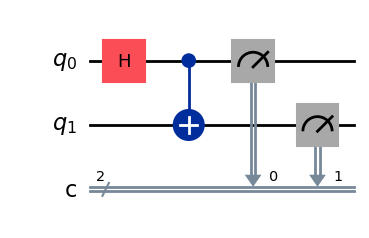

In [101]:
c=0
t=1
qucir=QuantumCircuit(2,2)
qucir.h(0)
qucir.cx(c,t)
qucir.measure([0,1], [0,1]) 
qucir.draw('mpl')

In [102]:
%%latex
CH=\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\ 
0 & 0 & \frac{1}{\sqrt{2}} & \frac{-1}{\sqrt{2}} 
\end{pmatrix}

<IPython.core.display.Latex object>

In [103]:
qucir.global_phase=np.pi/4
qucir.measure([0], [1])
print(qucir.data)
print('\n')
print(qucir.global_phase)

[CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=()), CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=()), CircuitInstruction(operation=Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=(<Clbit register=(2, "c"), index=0>,)), CircuitInstruction(operation=Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), qubits=(<Qubit register=(2, "q"), index=1>,), clbits=(<Clbit register=(2, "c"), index=1>,)), CircuitInstruction(operation=Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=(<Clbit register=(2, "c"), index=1>,))]


0.7853981633974483


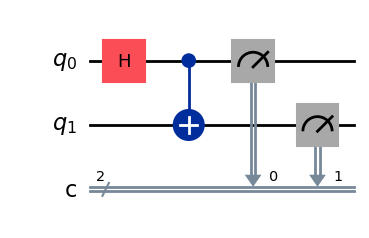

In [104]:
qc = QuantumCircuit(2, 2)
qc.h(0)          
qc.cx(0, 1)        
qc.measure([0,1], [0,1])  

# Draw the circuit
qc.draw('mpl')

In [105]:
job = bq_client.run(qc, job_name="test1", device="mps.cpu")
state_vector = job.get_counts()

[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: 6rgNrDUqLuoDYfdo, name: test1, device: mps.cpu, run status: RUNNING, created on: 2026-03-29 16:35:13 UTC, estimated runtime: 5000 ms, estimated cost: $0.00, num qubits: 2, shots: 1024


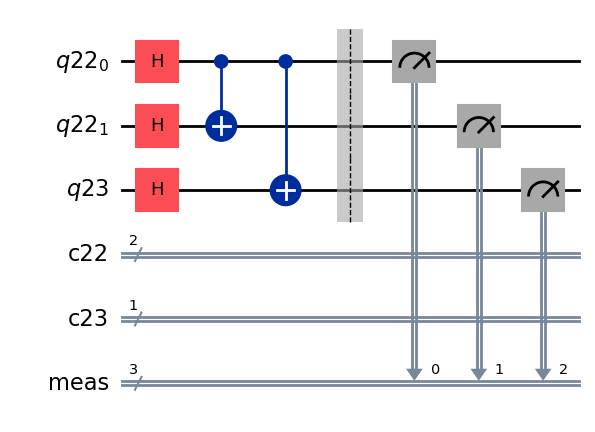

In [106]:
qr1 = QuantumRegister(2)
qr2 = QuantumRegister(1)
cr1 = ClassicalRegister(2)
cr2 = ClassicalRegister(1)
qcx = QuantumCircuit(qr1, qr2, cr1, cr2)
qcx.h(0)
qcx.h(1)
qcx.cx(0,1)
qcx.h(2)
qcx.cx(0,2)
qcx.measure_all()
# Draw the circuit
qcx.draw('mpl')

In [107]:
print("List the qubits in this circuit:", qcx.qubits)
print('\n')
print("List the classical bits in this circuit:", qcx.clbits)

List the qubits in this circuit: [<Qubit register=(2, "q22"), index=0>, <Qubit register=(2, "q22"), index=1>, <Qubit register=(1, "q23"), index=0>]


List the classical bits in this circuit: [<Clbit register=(2, "c22"), index=0>, <Clbit register=(2, "c22"), index=1>, <Clbit register=(1, "c23"), index=0>, <Clbit register=(3, "meas"), index=0>, <Clbit register=(3, "meas"), index=1>, <Clbit register=(3, "meas"), index=2>]


## **Layout**

[0, 1, 2]


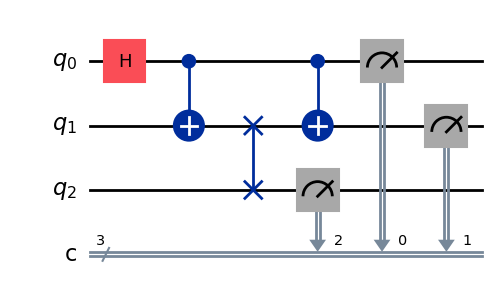

In [108]:
# Create circuit to test transpiler on
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.swap(1, 2)
qc.cx(0, 1)

# Add measurements to the circuit
qc.measure([0, 1, 2], [0, 1, 2])

# Specify the QPU to target
backend = GenericBackendV2(3)

# Transpile the circuit
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
transpiled = pass_manager.run(qc)

# Print the layout after transpilation
print(transpiled.layout.routing_permutation())
qc.draw('mpl')

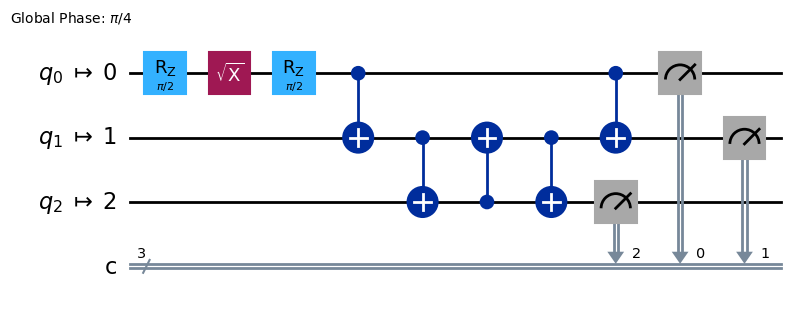

In [109]:
transpiled.draw('mpl')

In [110]:
print("List the qubits in this circuit:", qc.qubits)
print('\n')
print("List the classical bits in this circuit:", qc.clbits)

List the qubits in this circuit: [<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>]


List the classical bits in this circuit: [<Clbit register=(3, "c"), index=0>, <Clbit register=(3, "c"), index=1>, <Clbit register=(3, "c"), index=2>]


In [111]:
print("List the qubits in this circuit:", transpiled.qubits)
print('\n')
print("List the classical bits in this circuit:", transpiled.clbits)

List the qubits in this circuit: [<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>]


List the classical bits in this circuit: [<Clbit register=(3, "c"), index=0>, <Clbit register=(3, "c"), index=1>, <Clbit register=(3, "c"), index=2>]


Original circuit:


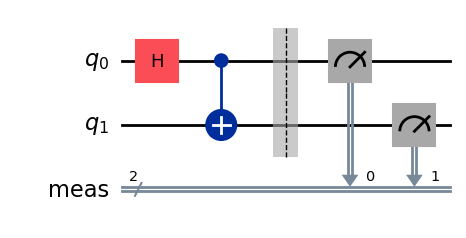

In [112]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# Print the original circuit
print("Original circuit:")
qc.draw('mpl')

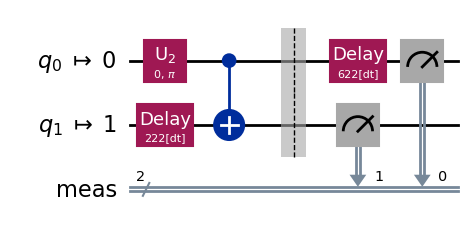

In [113]:
# Transpile the circuit with a specific basis gates 
backend = GenericBackendV2(2, basis_gates=['u1', 'u2', 'u3', 'cx'])
pm = generate_preset_pass_manager( optimization_level=1, backend=backend, scheduling_method="alap")
transpiled_qc = pm.run(qc)
transpiled_qc.draw('mpl')


In [114]:
print("Transpiled circuit with basis gates ['u1', 'u2', 'u3', 'cx']:")
print("Start times of instructions in the transpiled circuit:")
for instruction, start_time in zip(transpiled_qc.data, transpiled_qc.op_start_times):
    print(f"{instruction.operation.name}: {start_time}")

Transpiled circuit with basis gates ['u1', 'u2', 'u3', 'cx']:
Start times of instructions in the transpiled circuit:
u2: 0
delay: 0
cx: 222
barrier: 1102
delay: 1102
measure: 1724
measure: 1102


## **Parameterized Circuit**

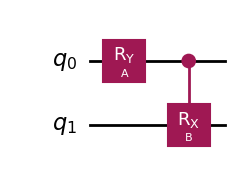

In [115]:
circuit = QuantumCircuit(2)
params = [Parameter('A'), Parameter('B'), Parameter('C')]
circuit.ry(params[0], 0)
circuit.crx(params[1], 0, 1)
circuit.draw('mpl')


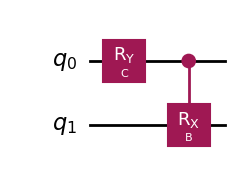

In [116]:
circuit.assign_parameters({params[0]: params[2]}, inplace=True)
circuit.draw('mpl')

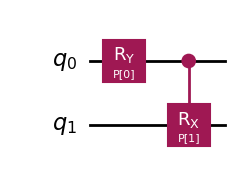

In [117]:
circuit = QuantumCircuit(2)
params = ParameterVector('P', 2)
circuit.ry(params[0], 0)
circuit.crx(params[1], 0, 1)
circuit.draw('mpl')

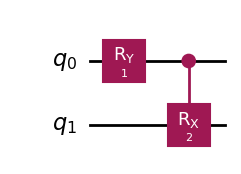

In [118]:
bound_circuit = circuit.assign_parameters([1, 2])
bound_circuit.draw('mpl')
